#Insatalling Libraries

In [99]:
!pip install imutils

# Importing Libraries

###### Libraries for data preprocessing and data visualization

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imutils import paths # imutils is a helper library for image processing tasks
import random
import time
import requests # A third-party Python library used to send HTTP requests (like a browser fetching a webpage).
import zipfile # A built-in Python library for working with .zip compressed files.
import json
from datetime import datetime

###### Libraries for images pre-processing and classification

In [101]:
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

##### Libraries for operating system

In [102]:
import os
import io # A built-in Python library for handling input/output streams (data in memory).


# Downlaoding The Image

In [103]:
# find the urk file

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/RdukW75jUsonAnS20t3n_g/training-an-image-classifier-w-2025-05-22-t-10-27-47-719-z.zip"
# Send a HTTP get request to the url
response = requests.get(url) # contain the status code, header, and file content

if response.status_code == 200:
  # Open the zip file
  with zipfile.ZipFile(io.BytesIO(response.content)) as zip_ref:
    zip_ref.extractall("cats_dogs")  # Unzip everything into "cats_dogs/" folder. Extract to the target folder
    print("Doanload and Extraction Completed..")
else:
  print("Faild to dowanload", response.status_code)

Doanload and Extraction Completed..


In [104]:
# Define the path of the annotations JSON file
annot_path = "cats_dogs/training-an-image-classifier-w-2025-05-22-t-10-27-47-719-z/_annotations.json"

# Load the JSON file
with open(annot_path, "r") as file:
  annotations = json.load(file)

# Now access to the first five entries
five_file = {k:annotations["annotations"][k] for k in list(annotations["annotations"])[:5]}
five_file

{'d3e2c989-2df0-448a-894b-73c72357d144.jpg': [{'label': 'cat',
   'id': 'ff776647-b5be-480c-87f6-84cefbdca45c'}],
 '7ffeaa61-34e6-4fa5-8539-8dac7c7be709.jpg': [{'label': 'dog',
   'id': 'befbe6b6-ea15-416a-bbf1-a17ea752faf4'}],
 'f5fd4d4f-cc77-4302-ba92-d208b76778ee.jpg': [{'label': 'dog',
   'id': '19fff04e-4a2f-4bcc-b4eb-e852098e7996'}],
 '80e7bab0-a96b-4e1d-8b9b-066333b757fa.jpg': [{'label': 'dog',
   'id': '3c342541-8e6b-46a5-9e5b-75750defc8e5'}],
 'fff311bd-531d-4d68-8298-2168480cee35.jpg': [{'label': 'cat',
   'id': '423cfab1-40d3-4458-a237-a900e5017788'}]}

# Load and Plot The Image

### Load Annotations File

In [105]:
# Define the base folder path

base_folder = "cats_dogs/training-an-image-classifier-w-2025-05-22-t-10-27-47-719-z"

annot_path = os.path.join(base_folder, "_annotations.json")

with open(annot_path, "r") as file:
  anntations = json.load(file)

print("Annotations loaded successfully")

Annotations loaded successfully


# Select a Random Image

In [106]:
#convet the annotations dictionary into a list
annot_list = list(annotations["annotations"].keys())
# Pick a random image from the annotations
random_image_name = random.choice(annot_list)

# Get the label for that image
label = annotations["annotations"][random_image_name][0]["label"]

print(f"Random Image: {random_image_name}")
print(f"Label: {label}")

Random Image: 640a6956-2981-44e0-b76d-974a50dbeb80.jpg
Label: dog


# Read and Convert The Image

In [107]:
# Construct full name to image
image_path = os.path.join(base_folder, random_image_name)

# Read the image using OpenCV
image = cv2.imread(image_path)
if image is None:
  raise NotFoundError(f"Image is not found at {image_path}")
else:
  print(f"The full image path:{image_path}")

The full image path:cats_dogs/training-an-image-classifier-w-2025-05-22-t-10-27-47-719-z/640a6956-2981-44e0-b76d-974a50dbeb80.jpg


# Image Processing

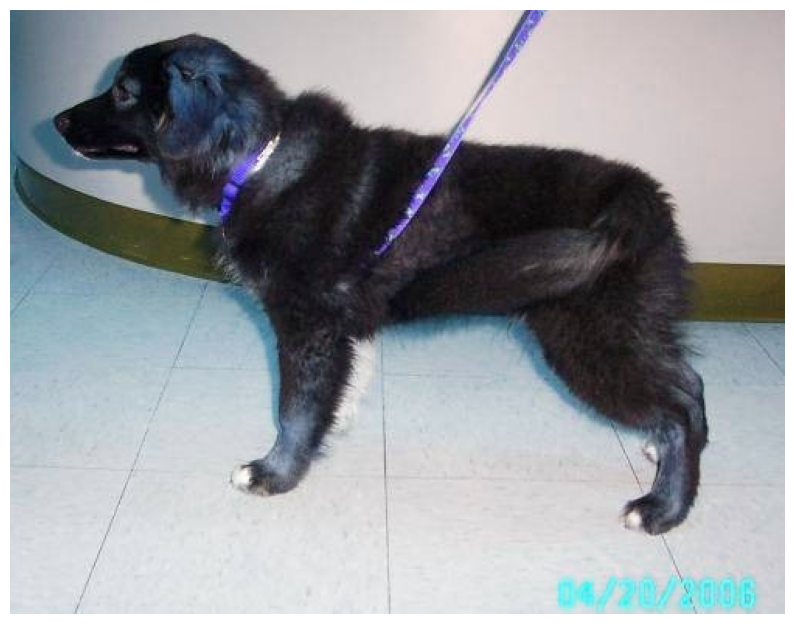

In [108]:
im_rgb = cv2.imread(image_path, cv2.COLOR_BGR2RGB)

# Visualization
plt.figure(figsize = (10,10))
plt.imshow(im_rgb)
plt.axis("off")
plt.show()

### Convet the image inot grayscale image

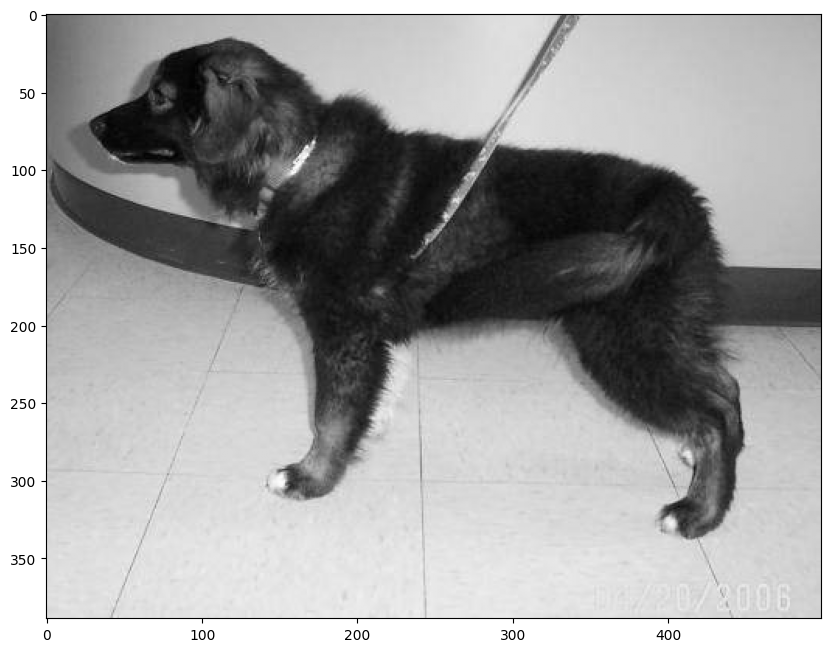

In [109]:
# Grayscale simplifies the algorithm and reduces computational requirements.

sample_image = cv2.cvtColor(im_rgb, cv2.COLOR_BGR2GRAY)
plt.figure(figsize = (10,10))
plt.imshow(sample_image, cmap = "gray")
plt.show()

### Resizing the image
###### Resizing image helps the algorithm train faster.

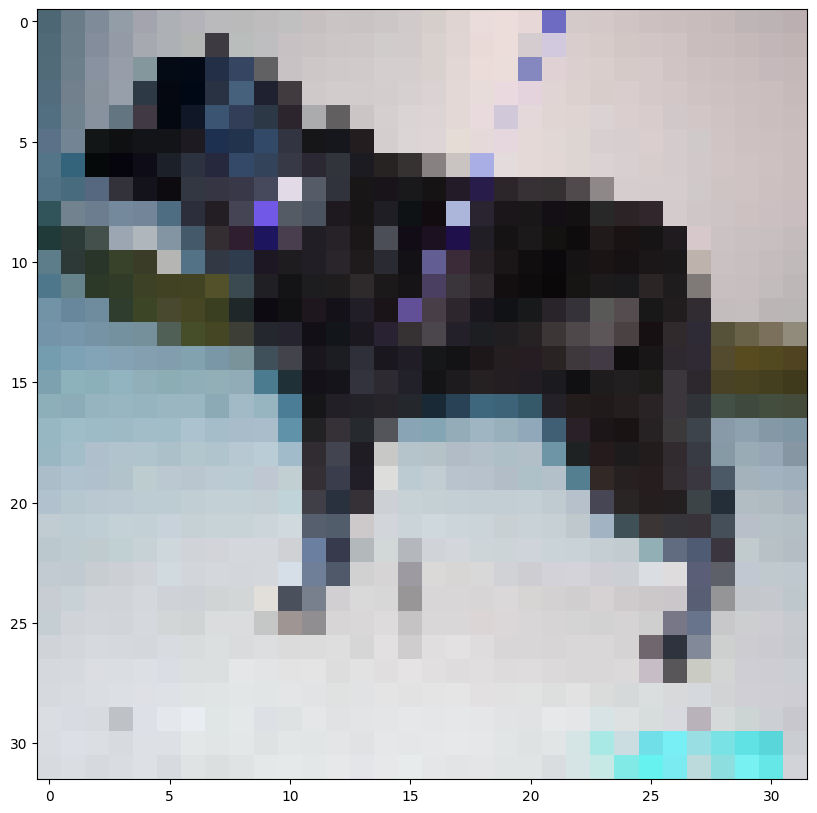

In [110]:
sample_image = cv2.resize(im_rgb, (32,32))

plt.figure(figsize = (10,10))
plt.imshow(sample_image, cmap = "gray")
plt.show()

### Flatten image
Makes the image a numpy array for the algorithm to handle and recognize.

In [111]:
pixels = sample_image.flatten()
pixels

array([ 77, 103, 116, ..., 209, 211, 216], dtype=uint8)

# Repeat the Process Above for All Images

In [112]:
# get all image file paths
image_paths = list(paths.list_images(base_folder))

train_images = []
train_labels = []

class_object = annotations["labels"]

In [113]:
from tqdm import tqdm #  is a Python library that shows a progress bar in the terminal

for image_path in tqdm(image_paths, desc = "loading images"):
  filename = os.path.basename(image_path)

  if filename not in annotations["annotations"]: # If the image has no label in the JSON file, we skip it
    continue

  # load image
  image = cv2.imread(image_path)
  image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
  image = cv2.resize(image, (32,32))
  pixels = image.flatten()  # Most AI/ML models take flat lists as input, not 2D grids

  # get label
  tmp_label = annotations["annotations"][filename][0]["label"]
  label = class_object.index(tmp_label)

  train_images.append(pixels)
  train_labels.append(label)

loading images: 100%|██████████| 800/800 [00:01<00:00, 537.35it/s]


In [114]:
train_images = np.array(train_images).astype("float32")
train_labels = np.array(train_labels).astype('int')
train_labels = train_labels.reshape((train_labels.size),1)
print(f"first 5 labels:{train_labels[:5]}")

first 5 labels:[[0]
 [1]
 [1]
 [0]
 [1]]


# Train a K-NN Classifier for Image Classification

In [115]:
print(f"The number of images:{len(train_images)}")
print(f"The number of labels:{len(train_labels)}")

The number of images:800
The number of labels:800


In [116]:
train_sample, test_sample, train_label, test_label = train_test_split(train_images, train_labels, test_size = 0.2,
                                                                      stratify = train_labels, random_state = 0)

In [117]:
start_datetime = datetime.now()

# Create a knn model from opencv ML module

knn = cv2.ml.KNearest_create()

# train the model
knn.train(train_sample, cv2.ml.ROW_SAMPLE, train_label)

# Define different values of k to evaluate
k_values = [1,2,3,4,5]
k_results = [] # We will store the prediction values in it

for k in k_values:
  ret, result, neighbours, dict = knn.findNearest(test_sample, k = k)
  k_results.append(result)


In [118]:
flatten = []
for res in k_results:
  flat_result = [item for sublist in res for item in sublist]
  flatten.append(flat_result)

In [119]:
end_datetime = datetime.now()
print(f"Trainig Duration: {end_datetime -start_datetime}")

Trainig Duration: 0:00:00.451674


In [120]:
# Create accuracy list to store the accuracy result and confusion matrix for each k in them.
acc_array = []
con_matrix = []

for k_res in k_results:
  labels_name = [0,1] # {0: cat, 1: dog}
  # We put this in the loop to sot values in the empty list above: "con_matrix"
  cm = confusion_matrix(test_label, k_res, labels = labels_name)
  con_matrix.append(cm)

  # Check wich predictions is correct and match with test_label
  matches = k_res == test_label
  # Count how many predictions are correct
  correct = np.count_nonzero(matches)

  # calculate accuracy
  accuracy = correct*100/result.size
  acc_array.append(accuracy)


# Store the accuracy values for each k in a dictionary
acc_dict = {k_values[i]:acc_array[i] for i in range(len(k_values))}

# Sort them
sorted_list = sorted(acc_dict.items())

print("Accuracy for each k:")
for k, acc in sorted_list:
  print(f"K = {k}: {acc}%")

Accuracy for each k:
K = 1: 100.0%
K = 2: 96.25%
K = 3: 94.375%
K = 4: 85.625%
K = 5: 78.125%


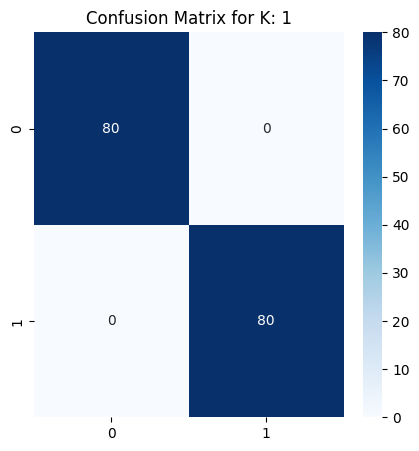

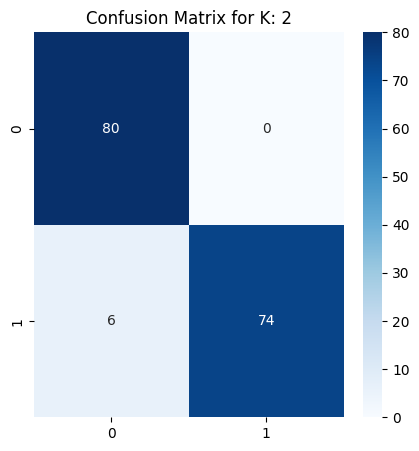

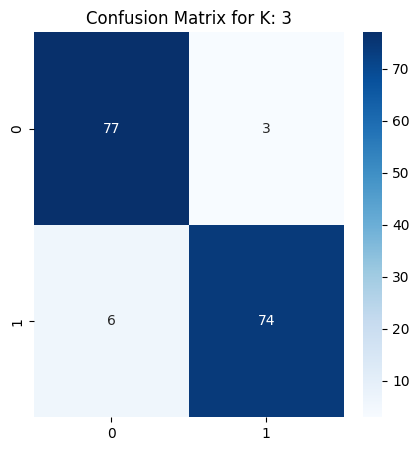

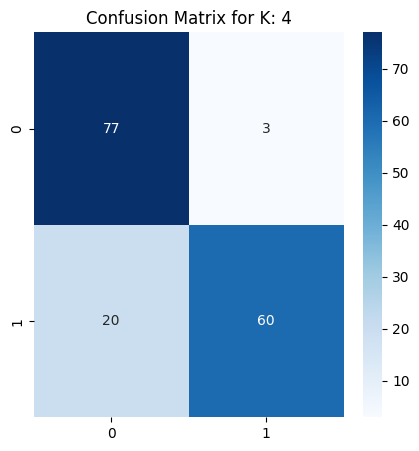

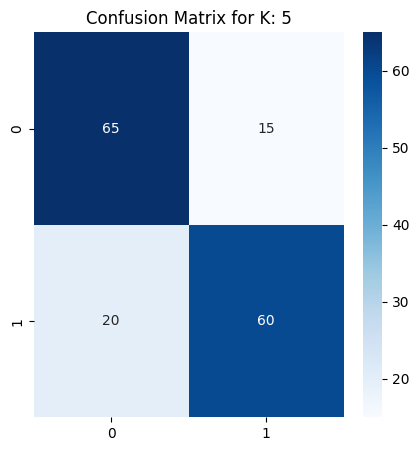

In [122]:
# PLot the confusion matrix for each k

from sklearn import metrics

c = 0 # counter for k values in the loop
for i in con_matrix:
  df = pd.DataFrame(i)
  plt.figure(figsize = (5,5))
  sns.heatmap(df, annot = True, cmap = "Blues", fmt = "g")

  c += 1
  plt.title(f"Confusion Matrix for K: {c}")
  plt.show()

In [123]:
con_matrix

[array([[80,  0],
        [ 0, 80]]),
 array([[80,  0],
        [ 6, 74]]),
 array([[77,  3],
        [ 6, 74]]),
 array([[77,  3],
        [20, 60]]),
 array([[65, 15],
        [20, 60]])]

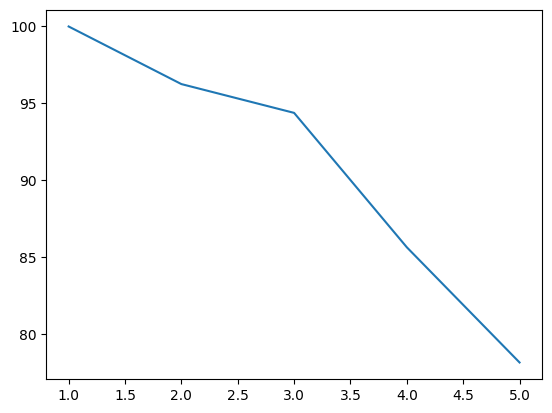

In [124]:
x, y = zip(*sorted_list)
plt.plot(x, y)
plt.show()

In [163]:
sorted_list

[(1, 100.0), (2, 96.25), (3, 94.375), (4, 85.625), (5, 78.125)]

In [162]:
# Get the best value of k
k_best = max(sorted_list, key = lambda item : item[1])[0]
k_best

100.0

In [137]:
knn.save("knn_samples.yml")

#Test the model by using differnt images from the local machine

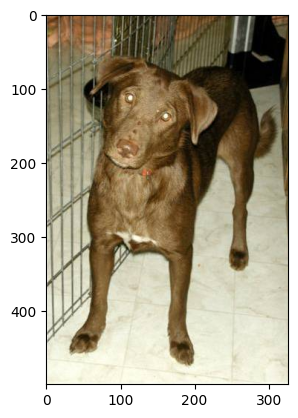

In [170]:
new_img = cv2.imread("dog.1.jpg")
new_img = cv2.cvtColor(new_img, cv2.COLOR_BGR2RGB)
plt.imshow(new_img)
plt.show()

In [171]:
new_img = cv2.cvtColor(new_img,cv2.COLOR_BGR2GRAY)

In [172]:
new_img = cv2.resize(new_img, (32, 32))

In [173]:
pixels_image = new_img.flatten()
pixels_image = np.array(pixels_image).astype("float32")

# Reshape pixels_image to be a 2D array (1 sample, 1024 features)
pixels_image_reshaped = pixels_image.reshape(1, -1)

ret, result, neighbours, dist = knn.findNearest(pixels_image_reshaped, k = sorted_list[3][0]) # We can use the k_best value too
print("Nearest Neighbours' Labels:\n", neighbours)
predicted_index = int(ret)
predicted_label = annotations["labels"][predicted_index]
print(f"Your image was classified as a **{predicted_label}**")

Nearest Neighbours' Labels:
 [[1. 1. 1. 1.]]
Your image was classified as a **cat**
